##### Name: Muhammad Huzaifa
##### Roll No: SU92-BSAIM-S24-010
##### Section: 4A
##### Subject: AI LAB TASK

# --------Task 6--------

## Libraries import

In [1]:
import cv2
import mediapipe as mp
import numpy as np
from flask import Flask

print("✅ OpenCV Version:", cv2.__version__)
print("✅ Mediapipe Imported Successfully")
print("✅ Flask Imported Successfully")
print("✅ Numpy Version:", np.__version__)


✅ OpenCV Version: 4.11.0
✅ Mediapipe Imported Successfully
✅ Flask Imported Successfully
✅ Numpy Version: 1.26.4


## Face Detection using MediaPipe

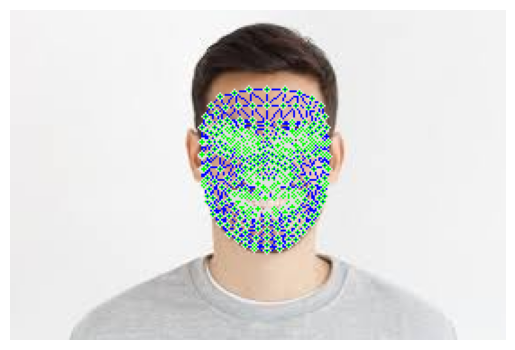

In [ ]:
import cv2
import mediapipe as mp
from matplotlib import pyplot as plt

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True)
mp_drawing = mp.solutions.drawing_utils

image_path = "Sample_image.jpeg"   
image = cv2.imread(image_path)
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
results = face_mesh.process(rgb_image)

if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        mp_drawing.draw_landmarks(
            image, face_landmarks, mp_face_mesh.FACEMESH_TESSELATION,
            mp_drawing.DrawingSpec(color=(0,255,0), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(255,0,0), thickness=1)
        )

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


## Facial Feature Measurement & Profile Generation

👁️ Eye Distance: 45.01
👄 Mouth Width: 37.01
🧠 Face Length: 89.0

🧩 Personality Profile: Balanced Personality


c:\Users\Dell\Documents\Sir Rasikh Tasks\Task6\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


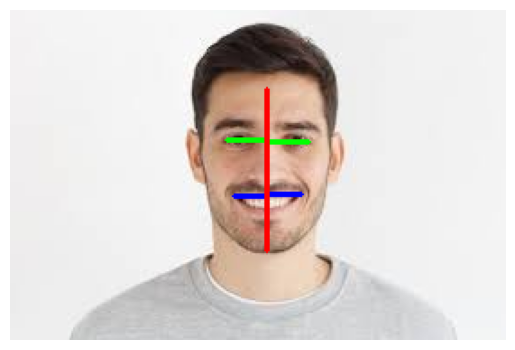

In [7]:
import math
import cv2
import mediapipe as mp
import numpy as np
from matplotlib import pyplot as plt

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True)

image_path = "Sample_image.jpeg"
image = cv2.imread(image_path)
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
results = face_mesh.process(rgb_image)

if results.multi_face_landmarks:
    face_landmarks = results.multi_face_landmarks[0]
    h, w, _ = image.shape
    
    landmarks = []
    for lm in face_landmarks.landmark:
        x, y = int(lm.x * w), int(lm.y * h)
        landmarks.append((x, y))

    left_eye = landmarks[33]   
    right_eye = landmarks[263]
    mouth_left = landmarks[61]
    mouth_right = landmarks[291]
    chin = landmarks[152]
    forehead = landmarks[10]

    # Distances
    eye_distance = math.dist(left_eye, right_eye)
    mouth_width = math.dist(mouth_left, mouth_right)
    face_length = math.dist(forehead, chin)

    print("👁️ Eye Distance:", round(eye_distance, 2))
    print("👄 Mouth Width:", round(mouth_width, 2))
    print("🧠 Face Length:", round(face_length, 2))


    if mouth_width > eye_distance * 0.9:
        personality = "Friendly and Expressive"
    elif face_length > eye_distance * 2.5:
        personality = "Calm and Thoughtful"
    else:
        personality = "Balanced Personality"

    print("\n🧩 Personality Profile:", personality)


    cv2.line(image, left_eye, right_eye, (0,255,0), 2)
    cv2.line(image, mouth_left, mouth_right, (255,0,0), 2)
    cv2.line(image, forehead, chin, (0,0,255), 2)

    
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
else:
    print("No face detected.")
